In [1]:
import pandas as pd
import numpy as np

In [4]:
tox21 = pd.read_csv('/Users/waningting/Desktop/tox21/tox21.csv', sep='\t')

In [5]:
tox21

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,ID,X
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX2725,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
7827,1.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,TOX2370,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
7828,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX2371,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
7829,1.0,1.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,TOX2377,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...


/var/folders/h5/vdbzpclj2x1cw2g07s9mdlcr0000gn/T/ipykernel_69809/1964220166.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


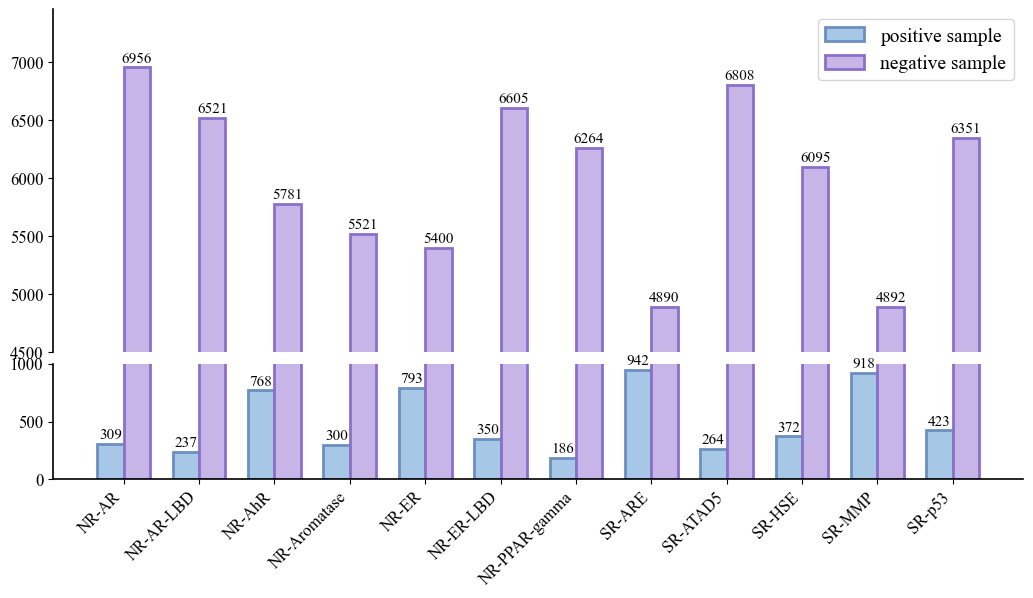

In [ ]:
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

df = tox21.copy()
target_cols = df.columns[:-2]

pos = np.array([(df[c] == 1).sum() for c in target_cols])
neg = np.array([(df[c] == 0).sum() for c in target_cols])

x = np.arange(len(target_cols))
width = 0.35


pos_facecolor = "#A7C7E7"     
pos_edgecolor = "#6B8FBF"     


neg_facecolor = "#C7B5E8"     
neg_edgecolor = "#8B70C9"     
bar_edge_width = 2.0           


mpl.rcParams["font.family"] = "Times New Roman"
tick_fontsize = 12
label_fontsize = 16
label_fontweight = "bold"
value_fontsize = 11
value_fontweight = "normal"
legend_fontsize = 14


spine_linewidth = 1.2


low_min, low_max = 0, 1000
high_min, high_max = 4500, neg.max() + 500

fig = plt.figure(figsize=(10, 5))

bax = brokenaxes(
    ylims=((low_min, low_max), (high_min, high_max)),
    hspace=0.05,
    fig=fig,
    diag_color="none"    
)

bax.bar(
    x - width/2, pos, width,
    label="positive sample",
    facecolor=pos_facecolor,
    edgecolor=pos_edgecolor,
    linewidth=bar_edge_width
)

bax.bar(
    x + width/2, neg, width,
    label="negative sample",
    facecolor=neg_facecolor,
    edgecolor=neg_edgecolor,
    linewidth=bar_edge_width
)

for i, v in enumerate(pos):
    if v <= low_max:
        bax.text(
            i - width/2, v + 20, str(v),
            ha='center', va='bottom',
            fontsize=value_fontsize,
            fontweight=value_fontweight
        )

for i, v in enumerate(neg):
    if v >= high_min:
        bax.text(
            i + width/2, v + 20, str(v),
            ha='center', va='bottom',
            fontsize=value_fontsize,
            fontweight=value_fontweight
        )

bax.axs[-1].set_xticks(x)
bax.axs[-1].set_xticklabels(
    target_cols,
    rotation=45,
    ha='right',
    fontsize=tick_fontsize
)

for ax in bax.axs:
    ax.tick_params(labelsize=tick_fontsize)
    ax.yaxis.get_label().set_fontsize(label_fontsize)
    ax.yaxis.get_label().set_fontweight(label_fontweight)

bax.legend(fontsize=legend_fontsize)

for ax in bax.axs:
    for spine in ax.spines.values():
        spine.set_linewidth(spine_linewidth)

plt.tight_layout()
#plt.show()
plt.savefig('figure1.jpg', dpi=300,bbox_inches='tight')










